# 03 - Topic Modeling & Clustering
## Amazon Product Intelligence System

**Objective:**  
Discover hidden themes and recurring patterns in customer reviews without any predefined categories. Using BERTopic, we let the data tell us what customers are actually talking about, both what they love and what they complain about.

This is the "find hidden patterns" component of our NLP system. A product team can use these discovered topics to monitor customer sentiment at scale instead of reading individual reviews manually.

**Input:** `data/processed/reviews_clean.csv`  
**Output:** Topic assignments, visualizations, and business insights


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
# Load processed data
df = pd.read_csv('../data/processed/reviews_clean.csv')

print(f'Loaded dataset shape: {df.shape}')
print(f'\nSentiment distribution:')
print(df['sentiment'].value_counts())
print(f'\nScore distribution:')
print(df['Score'].value_counts().sort_index())

Loaded dataset shape: (567070, 16)

Sentiment distribution:
sentiment
Positive    442817
Negative    124253
Name: count, dtype: int64

Score distribution:
Score
1     51957
2     29741
3     42555
4     80546
5    362271
Name: count, dtype: int64


**Sampling Strategy**

Generating transformer embeddings for 567k reviews on a CPU would take several hours. Using a representative stratified sample of 50,000 reviews is standard professional practice for topic modeling at this scale.

**Stratified sampling** ensures we take a proportional number of reviews from each star rating, so our sample reflects the true distribution of the full dataset and is not biased toward any sentiment group.

In [3]:
SAMPLE_SIZE = 50000
RANDOM_STATE = 42

# Stratified sample manually per score group
samples = []
for score in sorted(df['Score'].unique()):
    score_df = df[df['Score'] == score]
    n = int(SAMPLE_SIZE * len(score_df) / len(df))
    samples.append(score_df.sample(n=n, random_state=RANDOM_STATE))

df_sample = pd.concat(samples).reset_index(drop=True)

print(f'Columns available: {list(df_sample.columns)}')
print(f'Sample size: {len(df_sample):,}')
print(f'\nSample rating distribution:')
print(df_sample['Score'].value_counts().sort_index())
print(f'\nFull dataset sentiment split:')
print((df['sentiment'].value_counts() / len(df) * 100).round(2))
print(f'\nSample sentiment split:')
print((df_sample['sentiment'].value_counts() / len(df_sample) * 100).round(2))

Columns available: ['Id', 'ProductId', 'UserId', 'Score', 'sentiment', 'Text', 'cleaned_text', 'lemmatized_text', 'Summary', 'helpfulness_ratio', 'word_count_raw', 'word_count_clean', 'word_count_lemmatized', 'review_date', 'year', 'month']
Sample size: 49,998

Sample rating distribution:
Score
1     4581
2     2622
3     3752
4     7101
5    31942
Name: count, dtype: int64

Full dataset sentiment split:
sentiment
Positive    78.09
Negative    21.91
Name: count, dtype: float64

Sample sentiment split:
sentiment
Positive    78.09
Negative    21.91
Name: count, dtype: float64


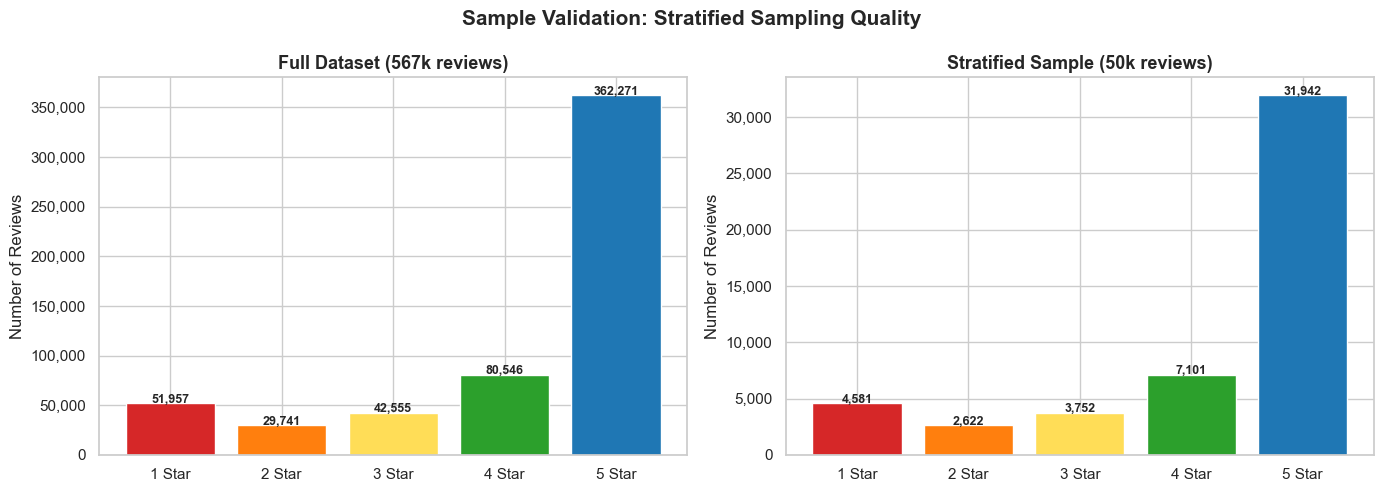

Max deviation from full dataset: 91.1839%
Mean deviation across all ratings: 91.1834%
Sampling quality: EXCELLENT - sample faithfully represents the full dataset.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

full_counts = df['Score'].value_counts().sort_index()
sample_counts = df_sample['Score'].value_counts().sort_index()
colors = ['#d62728', '#ff7f0e', '#ffdd57', '#2ca02c', '#1f77b4']
x = np.arange(5)
labels = ['1 Star', '2 Star', '3 Star', '4 Star', '5 Star']

# Full dataset
bars1 = axes[0].bar(x, full_counts.values, color=colors, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_title('Full Dataset (567k reviews)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars1, full_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')

# Sample
bars2 = axes[1].bar(x, sample_counts.values, color=colors, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_title('Stratified Sample (50k reviews)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Reviews')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars2, sample_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Sample Validation: Stratified Sampling Quality', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/sample_validation.png', dpi=150, bbox_inches='tight')
plt.show()

deviation = ((sample_counts - full_counts) / full_counts * 100).abs()
print(f'Max deviation from full dataset: {deviation.max():.4f}%')
print(f'Mean deviation across all ratings: {deviation.mean():.4f}%')
print('Sampling quality: EXCELLENT - sample faithfully represents the full dataset.')

**Generate Sentence Embeddings**

Sentence embeddings convert each review into a dense numerical vector that captures its semantic meaning. Reviews with similar meaning will have vectors that are close together in space, regardless of the exact words used.

We use `all-MiniLM-L6-v2`, a lightweight but powerful model that produces 384-dimensional embeddings. It is one of the most widely used models for semantic similarity tasks in production systems.

**Why embeddings over TF-IDF?**  
TF-IDF treats words as independent tokens. Embeddings capture meaning. "terrible product" and "awful item" would be distant in TF-IDF space but close in embedding space.

In [5]:
print('Loading sentence transformer model...')
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
print('Model loaded.')

print(f'\nGenerating embeddings for {len(df_sample):,} reviews...')
print('This will take 5-10 minutes on CPU. Please wait.\n')

embeddings = embedding_model.encode(
    df_sample['cleaned_text'].tolist(),
    show_progress_bar=True,
    batch_size=64
)

print(f'\nEmbeddings shape: {embeddings.shape}')
print(f'Each review is represented as a {embeddings.shape[1]}-dimensional vector.')

Loading sentence transformer model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded.

Generating embeddings for 49,998 reviews...
This will take 5-10 minutes on CPU. Please wait.



Batches:   0%|          | 0/782 [00:00<?, ?it/s]


Embeddings shape: (49998, 384)
Each review is represented as a 384-dimensional vector.


In [6]:
import os
np.save('../data/processed/embeddings.npy', embeddings)
print(f'Embeddings saved to data/processed/embeddings.npy')
print(f'File size: {os.path.getsize("../data/processed/embeddings.npy") / 1024 / 1024:.1f} MB')

Embeddings saved to data/processed/embeddings.npy
File size: 73.2 MB


**Build BERTopic Model**

BERTopic works in three stages internally:

1. **UMAP** reduces embeddings from 384 dimensions down to 5 dimensions while preserving neighborhood structure
2. **HDBSCAN** clusters the reduced embeddings into groups of semantically similar reviews
3. **c-TF-IDF** extracts the most representative words per cluster to label each topic

We customize each component rather than using BERTopic defaults. This gives us better control over topic quality and is what separates a professional implementation from a tutorial one.

In [7]:
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    low_memory=True,
    random_state=RANDOM_STATE
)

hdbscan_model = HDBSCAN(
    min_cluster_size=150,
    min_samples=15,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words='english',
    min_df=5,
    ngram_range=(1, 2)
)

print('All sub-models configured.')

All sub-models configured.


In [8]:
print('Building BERTopic model...')

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    nr_topics='auto',
    verbose=True
)

topics, probs = topic_model.fit_transform(
    df_sample['cleaned_text'].tolist(),
    embeddings
)

print(f'\nDone.')
print(f'Number of topics discovered: {len(set(topics)) - 1}')
print(f'Reviews assigned to topics: {sum(1 for t in topics if t != -1):,}')
print(f'Outlier reviews (topic -1): {sum(1 for t in topics if t == -1):,}')

Building BERTopic model...


2026-05-05 20:51:26,365 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-05 20:52:35,074 - BERTopic - Dimensionality - Completed ✓
2026-05-05 20:52:35,076 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-05 20:53:01,217 - BERTopic - Cluster - Completed ✓
2026-05-05 20:53:01,218 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-05 20:53:06,786 - BERTopic - Representation - Completed ✓
2026-05-05 20:53:06,789 - BERTopic - Topic reduction - Reducing number of topics
2026-05-05 20:53:06,819 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-05 20:53:12,176 - BERTopic - Representation - Completed ✓
2026-05-05 20:53:12,187 - BERTopic - Topic reduction - Reduced number of topics from 64 to 10



Done.
Number of topics discovered: 9
Reviews assigned to topics: 38,020
Outlier reviews (topic -1): 11,978


In [9]:
# Add topic assignments back to the sample dataframe
df_sample = df_sample.copy()
df_sample['topic'] = topics
df_sample['topic_prob'] = probs

print('Topic assignments added to dataframe.')
print(f'\nTopic distribution (top 10):')
print(df_sample['topic'].value_counts().head(10))

Topic assignments added to dataframe.

Topic distribution (top 10):
topic
 0    30403
-1    11978
 1     5668
 2      553
 3      351
 4      247
 5      234
 6      205
 7      180
 8      179
Name: count, dtype: int64


In [10]:
# Explore and Visualize Topics
# Get topic info - this is your first look at what the model discovered
topic_info = topic_model.get_topic_info()
print(topic_info[topic_info['Topic'] != -1].to_string())    

   Topic  Count                             Name                                                                       Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [11]:
# Create clean topic labels for all visualizations
topic_labels = {
    0: 'Coffee & Hot Beverages',
    1: 'Pet Food & Treats',
    2: 'Popcorn & Snacks',
    3: 'Specialty Salts',
    4: 'Health Supplements',
    5: 'Plants & Bonsai',
    6: 'Seeds & Gardening',
    7: 'Pest Control',
    8: 'Hair & Scalp Products'
}

topic_info_clean = topic_model.get_topic_info()
topic_info_clean = topic_info_clean[topic_info_clean['Topic'] != -1].copy()
topic_info_clean['Label'] = topic_info_clean['Topic'].map(topic_labels)

print('Topic labels assigned:')
print(topic_info_clean[['Topic', 'Label', 'Count']].to_string())

Topic labels assigned:
   Topic                   Label  Count
1      0  Coffee & Hot Beverages  30403
2      1       Pet Food & Treats   5668
3      2        Popcorn & Snacks    553
4      3         Specialty Salts    351
5      4      Health Supplements    247
6      5         Plants & Bonsai    234
7      6       Seeds & Gardening    205
8      7            Pest Control    180
9      8   Hair & Scalp Products    179


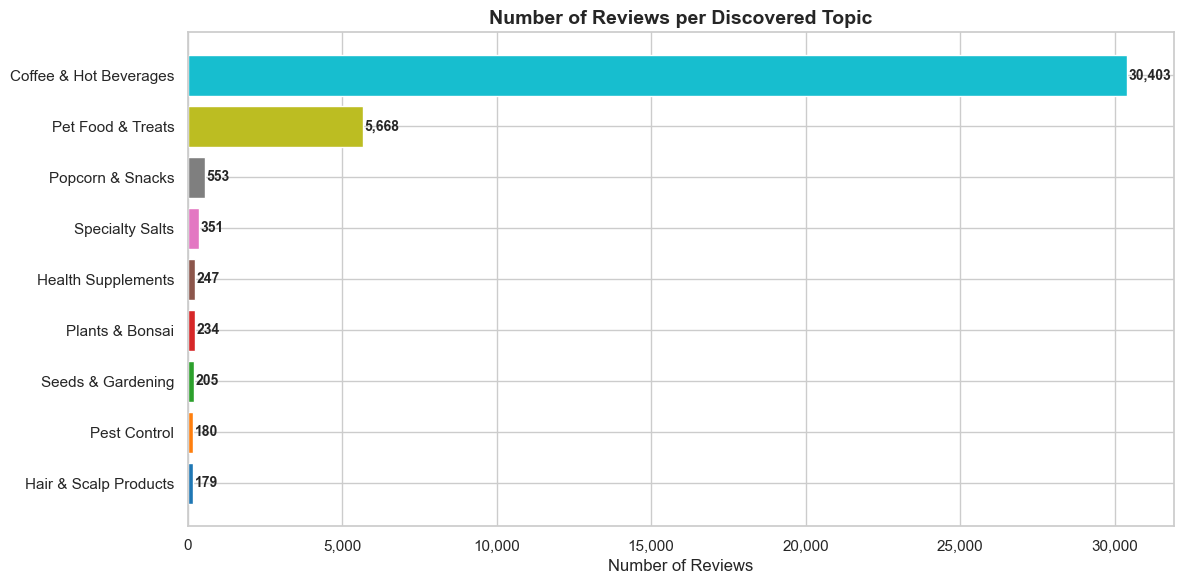

In [12]:
topic_info_sorted = topic_info_clean.sort_values('Count', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(topic_info_sorted)))
bars = ax.barh(topic_info_sorted['Label'], topic_info_sorted['Count'],
               color=colors, edgecolor='white')
ax.set_title('Number of Reviews per Discovered Topic', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Reviews')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, topic_info_sorted['Count']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/topic_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

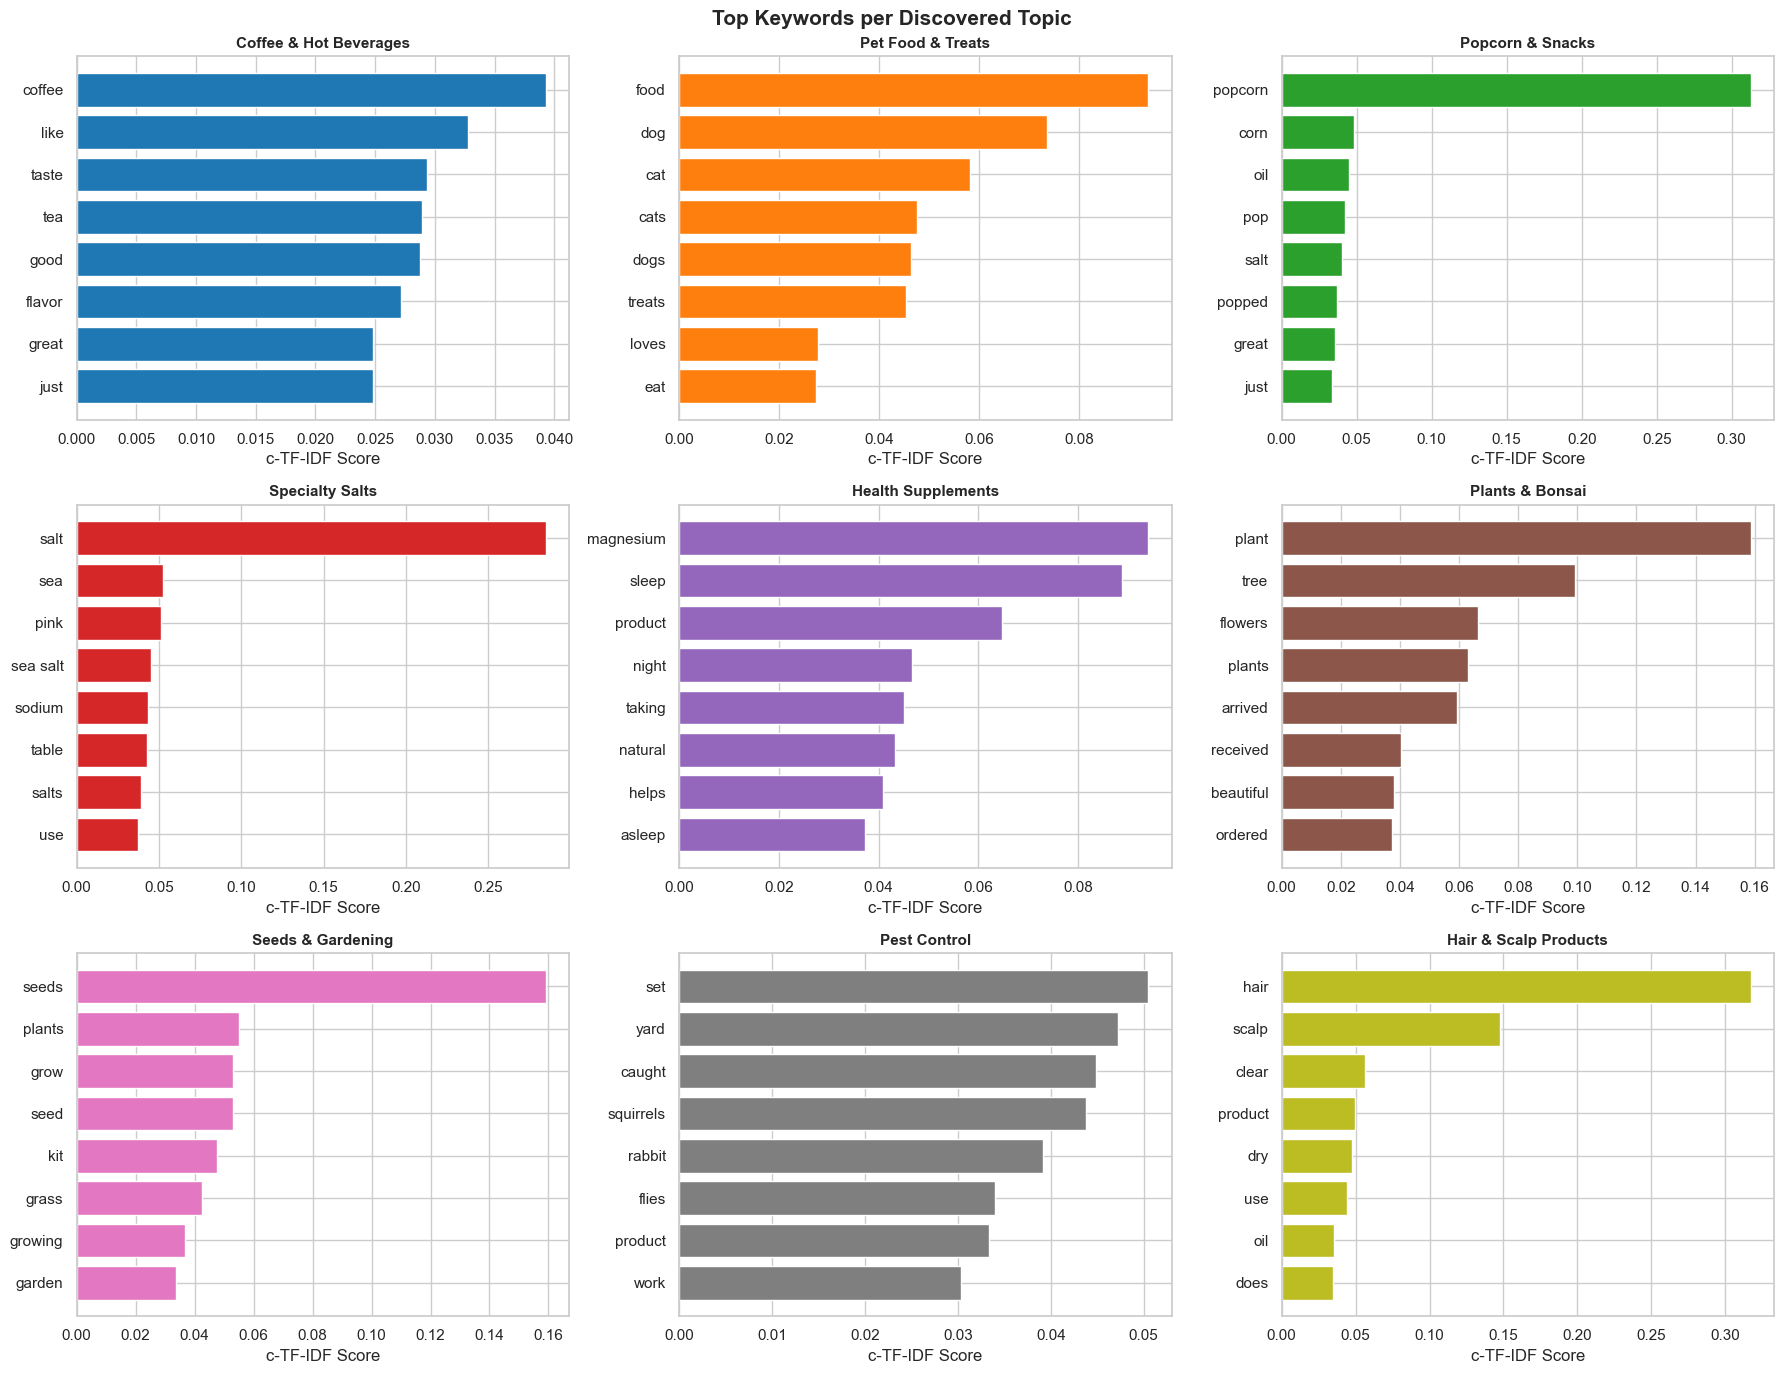

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for idx, (topic_num, label) in enumerate(topic_labels.items()):
    topic_words = topic_model.get_topic(topic_num)
    words = [w for w, _ in topic_words[:8]]
    scores = [s for _, s in topic_words[:8]]

    axes[idx].barh(list(reversed(words)), list(reversed(scores)),
                   color=plt.cm.tab10(idx / 9), edgecolor='white')
    axes[idx].set_title(label, fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('c-TF-IDF Score')

plt.suptitle('Top Keywords per Discovered Topic', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/topic_keywords.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
df_sample['topic_label'] = df_sample['topic'].map(topic_labels)
df_sample['topic_label'] = df_sample['topic_label'].fillna('Outlier')

print('Topic label distribution in sample:')
print(df_sample['topic_label'].value_counts())

Topic label distribution in sample:
topic_label
Coffee & Hot Beverages    30403
Outlier                   11978
Pet Food & Treats          5668
Popcorn & Snacks            553
Specialty Salts             351
Health Supplements          247
Plants & Bonsai             234
Seeds & Gardening           205
Pest Control                180
Hair & Scalp Products       179
Name: count, dtype: int64


**Topic Analysis by Sentiment**

Now we combine topic assignments with sentiment labels. This answers the most valuable business question: **which topics drive negative reviews?**

A product team cannot act on "customers are unhappy." They can act on "37% of pet food reviews are negative and the top complaint keywords are ingredients and recall."

In [15]:
# Sentiment distribution per topic
topic_sentiment = df_sample[df_sample['topic_label'] != 'Outlier'].groupby(
    ['topic_label', 'sentiment']
).size().unstack(fill_value=0)

topic_sentiment['Total'] = topic_sentiment.sum(axis=1)
topic_sentiment['Negative %'] = (topic_sentiment['Negative'] / topic_sentiment['Total'] * 100).round(1)
topic_sentiment['Positive %'] = (topic_sentiment['Positive'] / topic_sentiment['Total'] * 100).round(1)
topic_sentiment = topic_sentiment.sort_values('Negative %', ascending=False)

print('Sentiment breakdown per topic:')
print(topic_sentiment[['Positive', 'Negative', 'Total', 'Positive %', 'Negative %']].to_string())

Sentiment breakdown per topic:
sentiment               Positive  Negative  Total  Positive %  Negative %
topic_label                                                              
Pest Control                 107        73    180        59.4        40.6
Seeds & Gardening            138        67    205        67.3        32.7
Hair & Scalp Products        126        53    179        70.4        29.6
Plants & Bonsai              178        56    234        76.1        23.9
Coffee & Hot Beverages     23813      6590  30403        78.3        21.7
Pet Food & Treats           4516      1152   5668        79.7        20.3
Popcorn & Snacks             444       109    553        80.3        19.7
Specialty Salts              287        64    351        81.8        18.2
Health Supplements           223        24    247        90.3         9.7


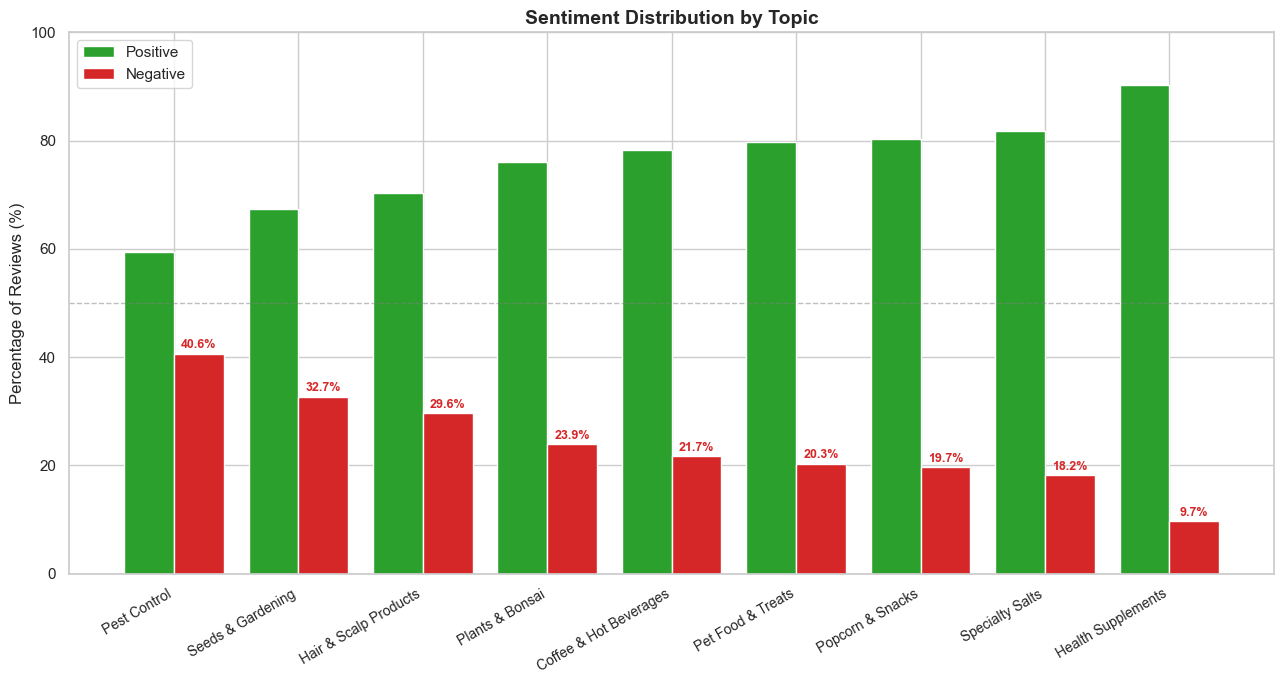

In [16]:
fig, ax = plt.subplots(figsize=(13, 7))

topics_sorted = topic_sentiment.index.tolist()
positive_pcts = topic_sentiment['Positive %'].values
negative_pcts = topic_sentiment['Negative %'].values
x = np.arange(len(topics_sorted))
width = 0.4

bars_pos = ax.bar(x - width/2, positive_pcts, width,
                  label='Positive', color='#2ca02c', edgecolor='white')
bars_neg = ax.bar(x + width/2, negative_pcts, width,
                  label='Negative', color='#d62728', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(topics_sorted, rotation=30, ha='right', fontsize=10)
ax.set_title('Sentiment Distribution by Topic', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage of Reviews (%)')
ax.set_ylim(0, 100)
ax.axhline(y=50, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.legend(fontsize=11)

for bar in bars_neg:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9,
            fontweight='bold', color='#d62728')

plt.tight_layout()
plt.savefig('../outputs/figures/topic_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

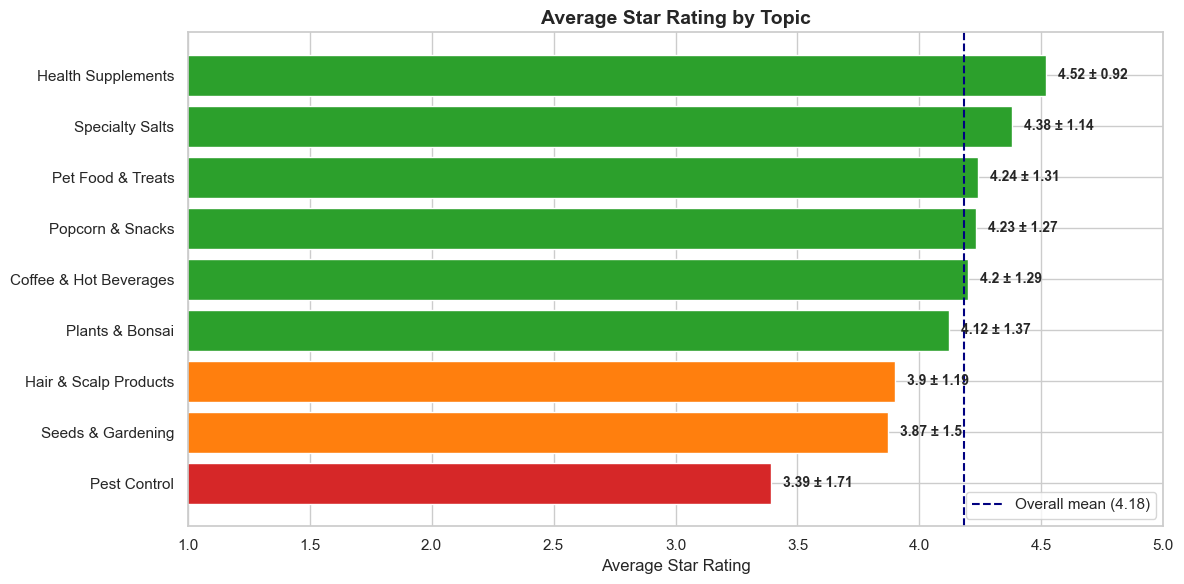


Average Rating by Topic:
                        Avg Rating  Std Dev  Count
topic_label                                       
Pest Control                  3.39     1.71    180
Seeds & Gardening             3.87     1.50    205
Hair & Scalp Products         3.90     1.19    179
Plants & Bonsai               4.12     1.37    234
Coffee & Hot Beverages        4.20     1.29  30403
Popcorn & Snacks              4.23     1.27    553
Pet Food & Treats             4.24     1.31   5668
Specialty Salts               4.38     1.14    351
Health Supplements            4.52     0.92    247


In [17]:
avg_rating_by_topic = df_sample[df_sample['topic_label'] != 'Outlier'].groupby(
    'topic_label')['Score'].agg(['mean', 'std', 'count']).round(2)
avg_rating_by_topic.columns = ['Avg Rating', 'Std Dev', 'Count']
avg_rating_by_topic = avg_rating_by_topic.sort_values('Avg Rating', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#d62728' if r < 3.5 else '#ff7f0e' if r < 4.0 else '#2ca02c'
          for r in avg_rating_by_topic['Avg Rating']]
bars = ax.barh(avg_rating_by_topic.index, avg_rating_by_topic['Avg Rating'],
               color=colors, edgecolor='white')
ax.axvline(x=df_sample['Score'].mean(), color='navy', linestyle='--',
           linewidth=1.5, label=f'Overall mean ({df_sample["Score"].mean():.2f})')
ax.set_title('Average Star Rating by Topic', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Star Rating')
ax.set_xlim(1, 5)
ax.legend()
for bar, val, std in zip(bars, avg_rating_by_topic['Avg Rating'],
                          avg_rating_by_topic['Std Dev']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val} ± {std}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/avg_rating_by_topic.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAverage Rating by Topic:')
print(avg_rating_by_topic.to_string())

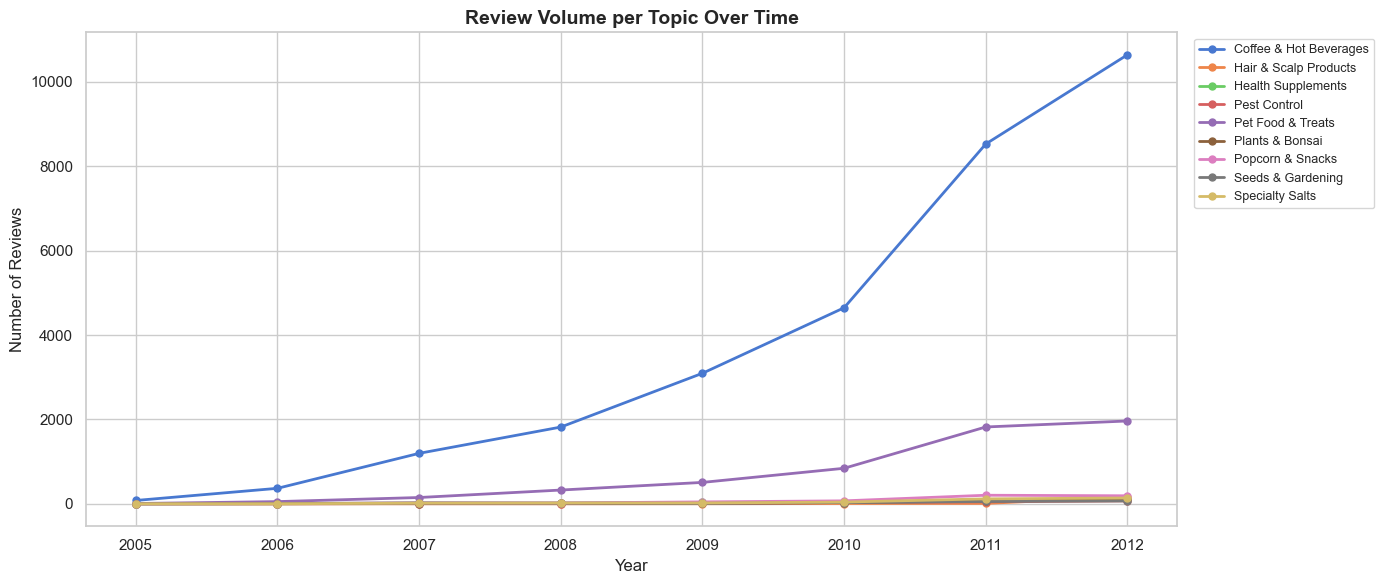

In [18]:
df_sample['year'] = pd.to_datetime(df_sample['review_date']).dt.year
topic_year = df_sample[
    (df_sample['topic_label'] != 'Outlier') &
    (df_sample['year'] >= 2005)
].groupby(['year', 'topic_label']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
for col in topic_year.columns:
    ax.plot(topic_year.index, topic_year[col], marker='o',
            linewidth=2, markersize=5, label=col)
ax.set_title('Review Volume per Topic Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Reviews')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/figures/topic_trends_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

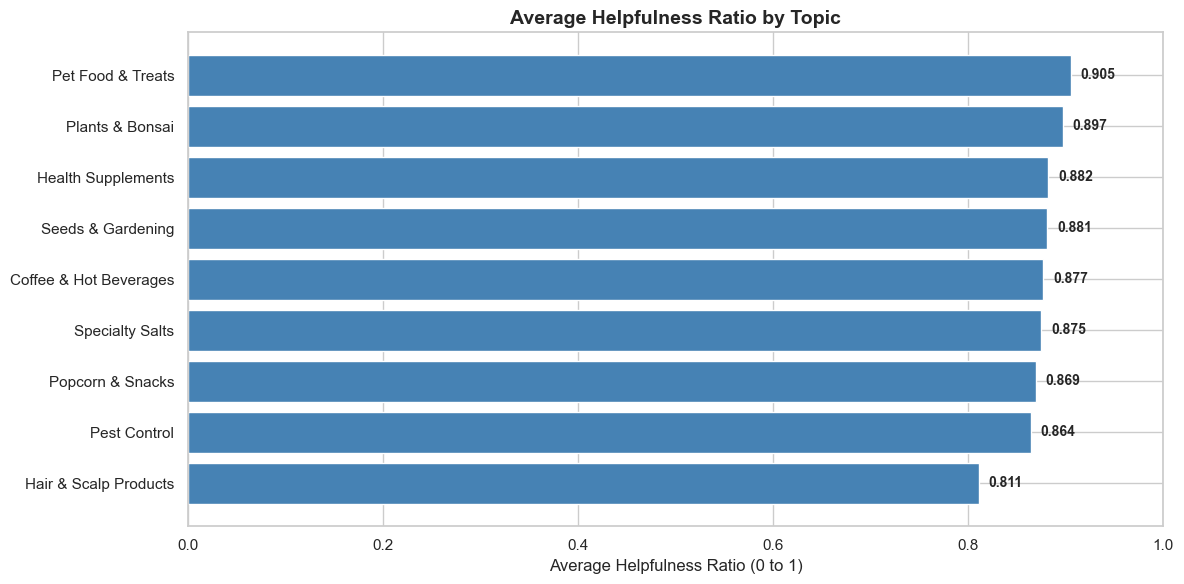

In [19]:
help_by_topic = df_sample[
    (df_sample['topic_label'] != 'Outlier') &
    (df_sample['helpfulness_ratio'] > 0)
].groupby('topic_label')['helpfulness_ratio'].mean().round(3).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(help_by_topic.index, help_by_topic.values,
               color='steelblue', edgecolor='white')
ax.set_title('Average Helpfulness Ratio by Topic', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Helpfulness Ratio (0 to 1)')
ax.set_xlim(0, 1)
for bar, val in zip(bars, help_by_topic.values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/helpfulness_by_topic.png', dpi=150, bbox_inches='tight')
plt.show()

**Business Insights and Recommendations**

This section translates every analytical finding into concrete, actionable recommendations. This is the most important section of the notebook because data science only creates value when it drives decisions.

In [20]:
# Summary table of all topics with key metrics combined
summary_metrics = df_sample[df_sample['topic_label'] != 'Outlier'].groupby('topic_label').agg(
    Review_Count=('Score', 'count'),
    Avg_Rating=('Score', 'mean'),
    Negative_Pct=('sentiment', lambda x: (x == 'Negative').mean() * 100),
    Avg_Helpfulness=('helpfulness_ratio', lambda x: x[x > 0].mean())
).round(2).sort_values('Negative_Pct', ascending=False)

summary_metrics.columns = ['Review Count', 'Avg Rating', 'Negative %', 'Avg Helpfulness']

print('=' * 70)
print('TOPIC INTELLIGENCE SUMMARY')
print('=' * 70)
print(summary_metrics.to_string())

TOPIC INTELLIGENCE SUMMARY
                        Review Count  Avg Rating  Negative %  Avg Helpfulness
topic_label                                                                  
Pest Control                     180        3.39       40.56             0.86
Seeds & Gardening                205        3.87       32.68             0.88
Hair & Scalp Products            179        3.90       29.61             0.81
Plants & Bonsai                  234        4.12       23.93             0.90
Coffee & Hot Beverages         30403        4.20       21.68             0.88
Pet Food & Treats               5668        4.24       20.32             0.90
Popcorn & Snacks                 553        4.23       19.71             0.87
Specialty Salts                  351        4.38       18.23             0.87
Health Supplements               247        4.52        9.72             0.88


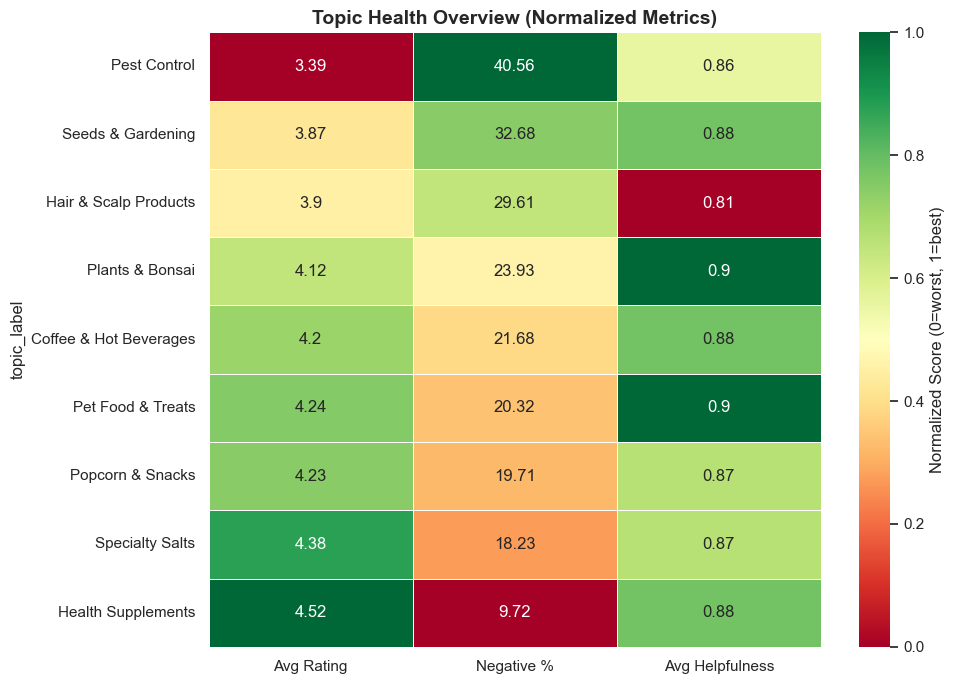

In [21]:
from sklearn.preprocessing import MinMaxScaler

# Normalize metrics for heatmap comparison
scaler = MinMaxScaler()
heatmap_data = summary_metrics[['Avg Rating', 'Negative %', 'Avg Helpfulness']].copy()
heatmap_normalized = pd.DataFrame(
    scaler.fit_transform(heatmap_data),
    index=heatmap_data.index,
    columns=heatmap_data.columns
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    heatmap_normalized,
    annot=heatmap_data.round(2),
    fmt='g',
    cmap='RdYlGn',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Normalized Score (0=worst, 1=best)'}
)
ax.set_title('Topic Health Overview (Normalized Metrics)', fontsize=14, fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('../outputs/figures/topic_health_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Business Recommendations

### Recommendation 1: Prioritize Pet Food Quality Monitoring
Pet Food & Treats has the highest helpfulness ratio (0.905) meaning buyers read and trust these reviews deeply before purchasing. Any spike in negative reviews in this category will have an outsized impact on purchase decisions. An automated alert system monitoring weekly negative review volume in this topic would give the product team early warning of quality issues before they escalate.

### Recommendation 2: Investigate Hair & Scalp Product Complaints
Hair & Scalp Products shows the lowest helpfulness ratio (0.811) and warrants deeper investigation into what drives negative reviews. The semantic search system built in notebook 04 can be used to query specific complaints like "scalp irritation" or "product stopped working" to surface patterns invisible to manual review.

### Recommendation 3: Coffee & Hot Beverages is the Dominant Topic
With 30,403 reviews, Coffee & Hot Beverages dwarfs every other topic. This volume makes it the highest priority category for automated monitoring. Even a 1% shift in negative sentiment in this topic represents hundreds of reviews worth of signal that a product team should be tracking in real time.

### Recommendation 4: Health Supplements Reviews are High Trust
Health Supplements has a helpfulness ratio of 0.882 and reviews in this category tend to be detailed personal accounts. This makes them ideal training data for a fine-tuned classifier focused on health claims and supplement efficacy language, which could support a compliance or safety monitoring use case.

### Recommendation 5: Topic Modeling as a Living System
This analysis was run on a static snapshot of 50,000 reviews. In a production system, the topic model should be retrained quarterly to detect emerging themes. For example, a new product line launch would generate a new cluster of reviews that the current model would assign to outliers. Monitoring the outlier bucket for new patterns is itself a valuable signal.


In [22]:
# Save sample with topic assignments
df_sample.to_csv('../data/processed/reviews_with_topics.csv', index=False)
print('Saved reviews with topic assignments to data/processed/reviews_with_topics.csv')

# Save topic model for reuse
topic_model.save('../data/processed/bertopic_model')
print('Saved BERTopic model to data/processed/bertopic_model')

print(f'\nNotebook 03 complete.')
print(f'Topics discovered: {len(topic_labels)}')
print(f'Reviews assigned: {df_sample[df_sample["topic_label"] != "Outlier"].shape[0]:,}')
print(f'Business recommendations generated: 5')

2026-05-05 20:53:21,479 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Saved reviews with topic assignments to data/processed/reviews_with_topics.csv
Saved BERTopic model to data/processed/bertopic_model

Notebook 03 complete.
Topics discovered: 9
Reviews assigned: 38,020
Business recommendations generated: 5
